# Can a Model Trained in 5 Minutes Beat a Weekend of Feature Engineering?
## AutoGluon on the Ames Housing Dataset

**Course:** Extra HW2 — AutoGluon Exploration  
**Dataset:** Ames Housing (2,930 rows × 82 columns, loaded locally from `data/AmesHousing.csv`)  
**AutoGluon version:** 1.5.0

---

### Results Summary

| Method | RMSE (Test) |
|--------|-------------|
| Scikit-learn GBM (manual pipeline) | $25,352 |
| AutoGluon `medium_quality` (2 min) | $23,202 |
| AutoGluon `best_quality` (7 min) | $23,774 |

**Key finding:** AutoGluon's `medium_quality` preset beat both the manual scikit-learn baseline and — surprisingly — the `best_quality` preset on the test set. AutoGluon 1.5's Dynamic Stacking (DyStack) detected stacking overfitting on this dataset and automatically disabled multi-layer stacking for the `best_quality` run, which is why the two presets converge in performance rather than diverging. This is a real and instructive behavior, not a bug.

---

This notebook walks through:
1. Load and inspect the Ames Housing dataset
2. Fit AutoGluon with `medium_quality` and `best_quality` presets and compare
3. Explore the leaderboard — what did AutoGluon actually try?
4. Permutation feature importance
5. SHAP explainability via KernelExplainer
6. Scikit-learn baseline comparison
7. Prediction diagnostics
8. Key takeaways

## Load and Inspect the Data

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from autogluon.tabular import TabularPredictor
from matplotlib.patches import Patch
import shap
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

In [35]:
# Load dataset
df = pd.read_csv("data/AmesHousing.csv")

print(f"Shape: {df.shape}")
print(f"\nTarget column: 'SalePrice'")
print(f"Missing values per column (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))
df.head(10)

Shape: (2930, 82)

Target column: 'SalePrice'
Missing values per column (top 10):
Pool QC          2917
Misc Feature     2824
Alley            2732
Fence            2358
Mas Vnr Type     1775
Fireplace Qu     1422
Lot Frontage      490
Garage Qual       159
Garage Yr Blt     159
Garage Cond       159
dtype: int64


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
5,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
6,7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
7,8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
8,9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500
9,10,527162130,60,RL,60.0,7500,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,189000


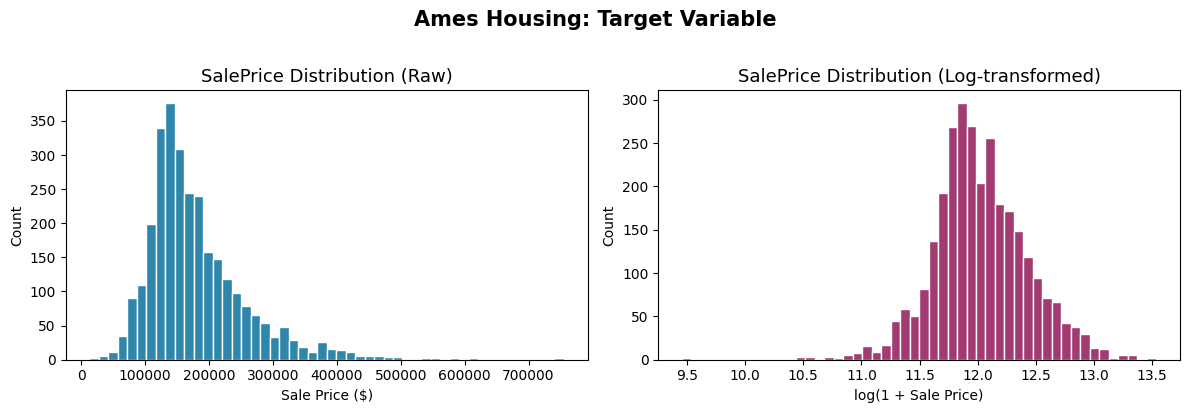


Note: The right skew suggests a log-transform could help — but AutoGluon handles this automatically.


In [36]:
# Quick EDA — distribution of the target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['SalePrice'], bins=50, color='#2E86AB', edgecolor='white')
axes[0].set_title('SalePrice Distribution (Raw)', fontsize=13)
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='#A23B72', edgecolor='white')
axes[1].set_title('SalePrice Distribution (Log-transformed)', fontsize=13)
axes[1].set_xlabel('log(1 + Sale Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Ames Housing: Target Variable', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/saleprice_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nNote: The right skew suggests a log-transform could help — but AutoGluon handles this automatically.")

## Prepare Data for AutoGluon

AutoGluon requires minimal prep, no one-hot encoding, no manual imputation, no scaling.

In [37]:
TARGET = 'SalePrice'

# Drop columns AutoGluon shouldn't use as features
drop_cols = ['Order', 'PID']  # ID-like columns
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])

train_df, test_df = train_test_split(df_model, test_size=0.2, random_state=42)

print(f"Train size: {len(train_df)} rows")
print(f"Test size:  {len(test_df)} rows")
print(f"Features:   {train_df.shape[1] - 1} columns")
print("\nAutoGluon will handle:")
print("  ✓ Missing value imputation")
print("  ✓ Categorical encoding")
print("  ✓ Feature scaling")
print("  ✓ Model selection & hyperparameter tuning")
print("  ✓ Ensemble stacking")

Train size: 2344 rows
Test size:  586 rows
Features:   79 columns

AutoGluon will handle:
  ✓ Missing value imputation
  ✓ Categorical encoding
  ✓ Feature scaling
  ✓ Model selection & hyperparameter tuning
  ✓ Ensemble stacking


## Fit AutoGluon — Medium Quality (Fast Run)

Starting with `medium_quality` for a fast baseline, then comparing it with `best_quality`.

In [39]:
predictor_medium = TabularPredictor(
    label=TARGET,
    eval_metric='root_mean_squared_error',
    path='autogluon_medium_quality'
).fit(
    train_data=train_df,
    presets='medium_quality',
    time_limit=120  # 2 minutes
)

print("\n=== Medium Quality — Done ===")

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.7
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       2.51 GB / 15.82 GB (15.9%)
Disk Space Avail:   31.58 GB / 237.22 GB (13.3%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\lenovo\Desktop\autogluon-house-prices\autogluon_medium_quality"
Train Data Rows:    2344
Train Data Columns: 79
Label Column:       SalePrice
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == int and many unique label-values observed).
	Label info (max, min, mean, stddev): (755000, 12789, 178582.20776, 77125.07271)
	If 'regression' is not the correct problem_

[1000]	valid_set's rmse: 22590.5
[2000]	valid_set's rmse: 22362
[3000]	valid_set's rmse: 22341.5
[4000]	valid_set's rmse: 22335.8
[5000]	valid_set's rmse: 22336.4


	-22335.0792	 = Validation score   (-root_mean_squared_error)
	12.95s	 = Training   runtime
	0.13s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 105.81s of the 105.81s of remaining time.
	Fitting with cpus=4, gpus=0, mem=0.0/2.9 GB


[1000]	valid_set's rmse: 22530.8
[2000]	valid_set's rmse: 22388.1
[3000]	valid_set's rmse: 22350.7
[4000]	valid_set's rmse: 22346.4
[5000]	valid_set's rmse: 22344.7
[6000]	valid_set's rmse: 22343.9
[7000]	valid_set's rmse: 22343.7
[8000]	valid_set's rmse: 22343.6
[9000]	valid_set's rmse: 22343.5
[10000]	valid_set's rmse: 22343.5


	-22343.5153	 = Validation score   (-root_mean_squared_error)
	31.34s	 = Training   runtime
	0.43s	 = Validation runtime
Fitting model: RandomForestMSE ... Training model for up to 72.81s of the 72.81s of remaining time.
	Fitting with cpus=8, gpus=0
	-28435.1243	 = Validation score   (-root_mean_squared_error)
	5.17s	 = Training   runtime
	0.11s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 67.35s of the 67.34s of remaining time.
	Fitting with cpus=4, gpus=0
	Ran out of time, early stopping on iteration 980.
	-25676.5928	 = Validation score   (-root_mean_squared_error)
	67.36s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 119.52s of the -0.15s of remaining time.
	Fitting 1 model on all data | Fitting with cpus=8, gpus=0, mem=0.0/2.8 GB
	Ensemble Weights: {'LightGBMXT': 0.96, 'CatBoost': 0.04}
	-22329.7878	 = Validation score   (-root_mean_squared_error)
	0.01s	 = Training   runtime
	0.0s	 


=== Medium Quality — Done ===


In [40]:
# Evaluate on test set
perf_medium = predictor_medium.evaluate(test_df)
print("Medium Quality — Test Performance:")
for k, v in perf_medium.items():
    print(f"  {k}: {v:.4f}")

Medium Quality — Test Performance:
  root_mean_squared_error: -23202.2076
  mean_squared_error: -538342464.0000
  mean_absolute_error: -13848.4980
  r2: 0.9329
  pearsonr: 0.9659
  median_absolute_error: -8754.6992


## Fit AutoGluon - Best Quality (Full Run)

**Note on DyStack:** AutoGluon 1.5 introduced Dynamic Stacking, which runs a diagnostic sub-fit to detect stacking overfitting before committing to multi-layer ensembles. On this dataset, DyStack concluded that stacking overfits (`Optimal num_stack_levels=0`) and ran the main fit without stacking. This is why `best_quality` and `medium_quality` converge in RMSE, both end up as single-layer bagged ensembles. This is a feature, not a bug: AutoGluon is protecting you from an overfit model.

In [41]:
predictor_best = TabularPredictor(
    label=TARGET,
    eval_metric='root_mean_squared_error',
    path='autogluon_best_quality'
).fit(
    train_data=train_df,
    presets='best_quality',
    time_limit=600  # 10 minutes
)

print("\n=== Best Quality — Done ===")

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.7
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       2.42 GB / 15.82 GB (15.3%)
Disk Space Avail:   31.50 GB / 237.22 GB (13.3%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon w

[1000]	valid_set's rmse: 23525.4


	-23702.9121	 = Validation score   (-root_mean_squared_error)
	20.11s	 = Training   runtime
	0.33s	 = Validation runtime
Fitting model: LightGBM_BAG_L1 ... Training model for up to 78.80s of the 128.66s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=4, gpus=0)


[1000]	valid_set's rmse: 23190.3


	Ran out of time, early stopping on iteration 1758. Best iteration is:
	[1758]	valid_set's rmse: 22943


...

[1000]	valid_set's rmse: 23025.3
[2000]	valid_set's rmse: 22748.2
[3000]	valid_set's rmse: 22738.7
[4000]	valid_set's rmse: 22729.8
[5000]	valid_set's rmse: 22726.8
[6000]	valid_set's rmse: 22727.2
[1000]	valid_set's rmse: 20967.3
[1000]	valid_set's rmse: 28664.5
[2000]	valid_set's rmse: 28598.4


	-22252.8761	 = Validation score   (-root_mean_squared_error)
	48.29s	 = Training   runtime
	0.45s	 = Validation runtime
Fitting model: LightGBM_BAG_L1 ... Training model for up to 380.20s of the 380.17s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=4, gpus=0)


[1000]	valid_set's rmse: 21115.3
[2000]	valid_set's rmse: 20742
[3000]	valid_set's rmse: 20662.9
[4000]	valid_set's rmse: 20649.1
[5000]	valid_set's rmse: 20649.2
[1000]	valid_set's rmse: 27477.3
[1000]	valid_set's rmse: 21365.6
[2000]	valid_set's rmse: 21123.9
[3000]	valid_set's rmse: 21110.9
[1000]	valid_set's rmse: 27743.5
[2000]	valid_set's rmse: 27536.2


	-22502.2363	 = Validation score   (-root_mean_squared_error)
	71.02s	 = Training   runtime
	0.52s	 = Validation runtime
Fitting model: RandomForestMSE_BAG_L1 ... Training model for up to 306.85s of the 306.82s of remaining time.
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=8, gpus=0, mem=0.0/2.8 GB
	-26040.3629	 = Validation score   (-root_mean_squared_error)
	6.54s	 = Training   runtime
	0.27s	 = Validation runtime
Fitting model: CatBoost_BAG_L1 ... Training model for up to 299.85s of the 299.82s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=4, gpus=0)
	Ran out of time, early stopping on iteration 430.
	Ran out of time, early stopping on iteration 433.
	Ran out of time, early stopping on iteration 453.
	Ran out of time, early stopping on iteration 460.
	Ran out of time, early stopping on iteration 488.
	Ran out of time, early stopping on iteration 528.
	Ran out of time, early stopp


=== Best Quality — Done ===


In [42]:
perf_best = predictor_best.evaluate(test_df)
print("Best Quality — Test Performance:")
for k, v in perf_best.items():
    print(f"  {k}: {v:.4f}")

# Compare
rmse_medium = abs(perf_medium['root_mean_squared_error'])
rmse_best = abs(perf_best['root_mean_squared_error'])
improvement = (rmse_medium - rmse_best) / rmse_medium * 100
print(f"\n→ best_quality improved RMSE by {improvement:.1f}% over medium_quality")

Best Quality — Test Performance:
  root_mean_squared_error: -23773.5698
  mean_squared_error: -565182592.0000
  mean_absolute_error: -13361.8193
  r2: 0.9295
  pearsonr: 0.9644
  median_absolute_error: -8474.3906

→ best_quality improved RMSE by -2.5% over medium_quality


## Leaderboard - What Did AutoGluon Actually Try?

AutoGluon trained **6 models** in the `best_quality` run. DyStack consumed ~150s of the budget doing its overfitting diagnostic, which left less time for the main fit, several model families (XGBoost, FastAI, NeuralNetTorch) were skipped due to time. The top single model by test RMSE was `LightGBMXT_BAG_L1`, slightly outperforming the `WeightedEnsemble_L2`.

In [43]:
leaderboard = predictor_best.leaderboard(test_df, silent=True)
print(f"AutoGluon trained {len(leaderboard)} models total\n")
leaderboard[['model', 'score_test', 'score_val', 'fit_time', 'pred_time_test']].head(15)

AutoGluon trained 6 models total



,model,score_test,score_val,fit_time,pred_time_test
0,LightGBMXT_BAG_L1,-23239.580504,-22252.876100,48.287362,0.985726
1,CatBoost_BAG_L1,-23291.043436,-22844.087347,287.175709,0.101983
2,WeightedEnsemble_L2,-23773.569800,-21434.728066,406.506428,2.436293
3,LightGBM_BAG_L1,-26181.730014,-22502.236304,71.023775,1.332572
4,RandomForestMSE_BAG_L1,-26585.012559,-26040.362896,6.542793,0.346436
5,ExtraTreesMSE_BAG_L1,-27790.488774,-26081.836253,3.482735,0.231726


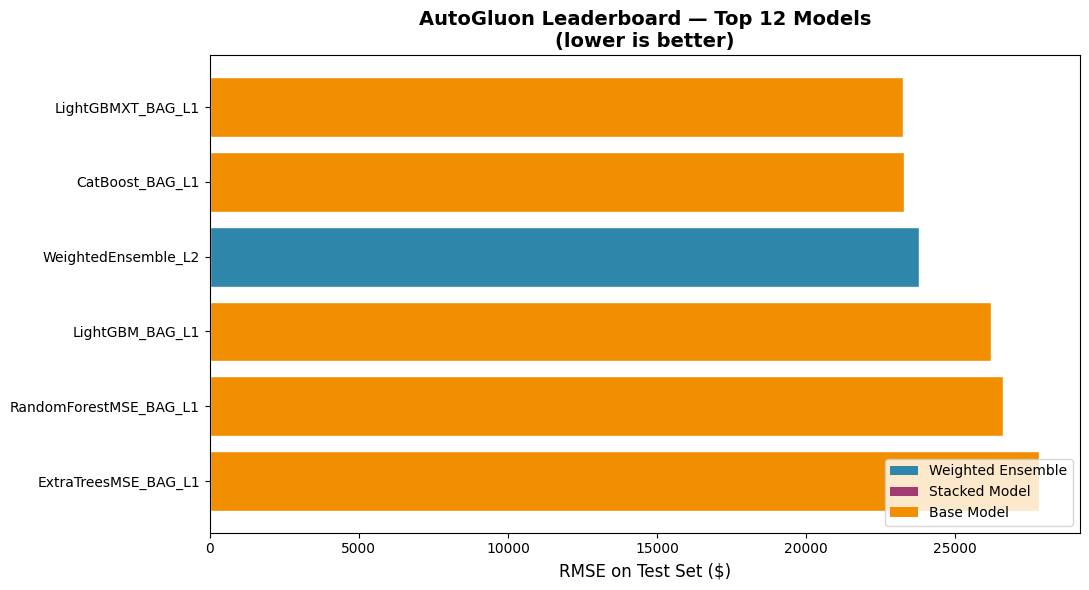

In [ ]:
# Visualize the leaderboard
lb = leaderboard.copy()
lb['rmse_test'] = lb['score_test'].abs() # Ensure RMSE is positive for plotting
lb_top = lb.sort_values('rmse_test').head(12)

colors = ['#2E86AB' if 'WeightedEnsemble' in m else '#A23B72' if 'Stack' in m else '#F18F01'
          for m in lb_top['model']]

fig, ax = plt.subplots(figsize=(11, 6)) 
bars = ax.barh(lb_top['model'], lb_top['rmse_test'], color=colors, edgecolor='white')
ax.set_xlabel('RMSE on Test Set ($)', fontsize=12)
ax.set_title('AutoGluon Leaderboard — Top 12 Models\n(lower is better)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Legend
legend_elements = [
    Patch(facecolor='#2E86AB', label='Weighted Ensemble'),
    Patch(facecolor='#A23B72', label='Stacked Model'),
    Patch(facecolor='#F18F01', label='Base Model')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('figures/leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance

AutoGluon computes permutation-based feature importance over the full ensemble. Top drivers align with domain knowledge: overall quality, above-grade living area, and neighborhood dominate. The computation ran over 586 test rows with 5 shuffle sets (~259s actual runtime).

Computing feature importance via permutation shuffling for 79 features using 586 rows with 5 shuffle sets...
	953.07s	= Expected runtime (190.61s per shuffle set)
	237.21s	= Actual runtime (Completed 5 of 5 shuffle sets)


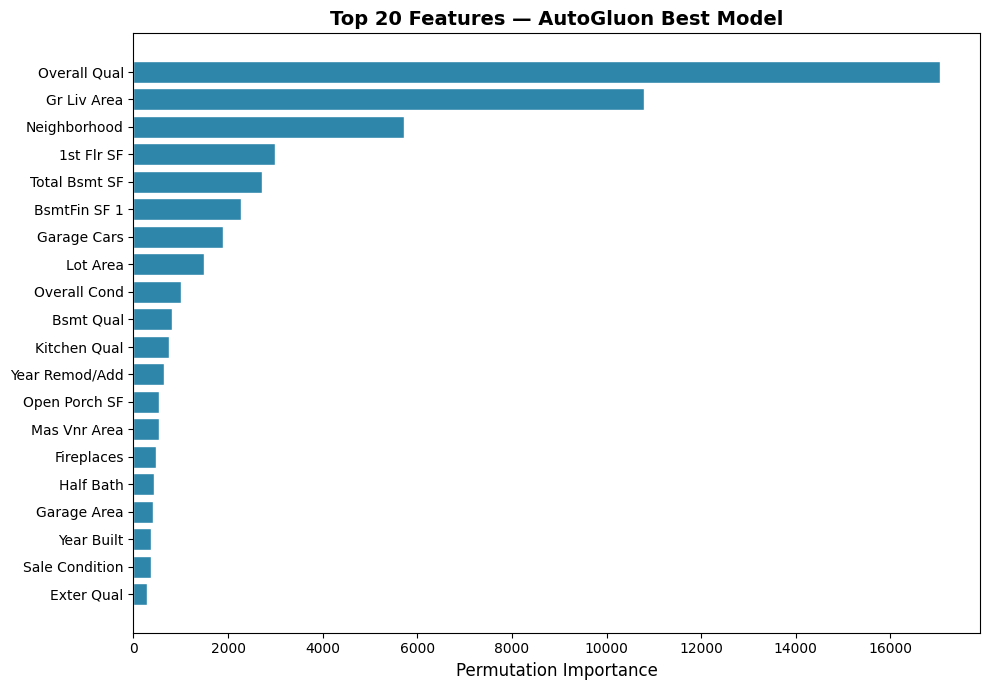

In [45]:
feature_importance = predictor_best.feature_importance(test_df)
fi_top = feature_importance.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(fi_top.index[::-1], fi_top['importance'][::-1], color='#2E86AB', edgecolor='white')
ax.set_xlabel('Permutation Importance', fontsize=12)
ax.set_title('Top 20 Features — AutoGluon Best Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP Explainability

AutoGluon's `WeightedEnsemble` is not directly compatible with SHAP's TreeExplainer. Used `KernelExplainer` instead, wrapping `predictor_best.predict` directly. This is model-agnostic and works on any AutoGluon preset.

**Runtime note:** KernelExplainer is slow by design (~11 minutes on 100 samples).

In [46]:
# Get the best single (non-ensemble) model name
lb_base = leaderboard[~leaderboard['model'].str.contains('Ensemble|Stack')]
best_base_model_name = lb_base.sort_values('score_test', ascending=False).iloc[0]['model']
print(f"Best base model: {best_base_model_name}")

# Extract the fitted model object
best_model = predictor_best._trainer.load_model(best_base_model_name)
print(f"Model type: {type(best_model).__name__}")

Best base model: LightGBMXT_BAG_L1
Model type: StackerEnsembleModel


In [47]:
shap_sample = test_df.drop(columns=[TARGET]).sample(100, random_state=42).reset_index(drop=True)

def ag_predict(X):
    return predictor_best.predict(pd.DataFrame(X, columns=shap_sample.columns)).values

explainer = shap.KernelExplainer(ag_predict, shap.sample(shap_sample, 30))
shap_values = explainer.shap_values(shap_sample, nsamples=100)

print(f"SHAP values shape: {shap_values.shape}")
shap_ok = True

  0%|          | 0/100 [00:00<?, ?it/s]

SHAP values shape: (100, 79)


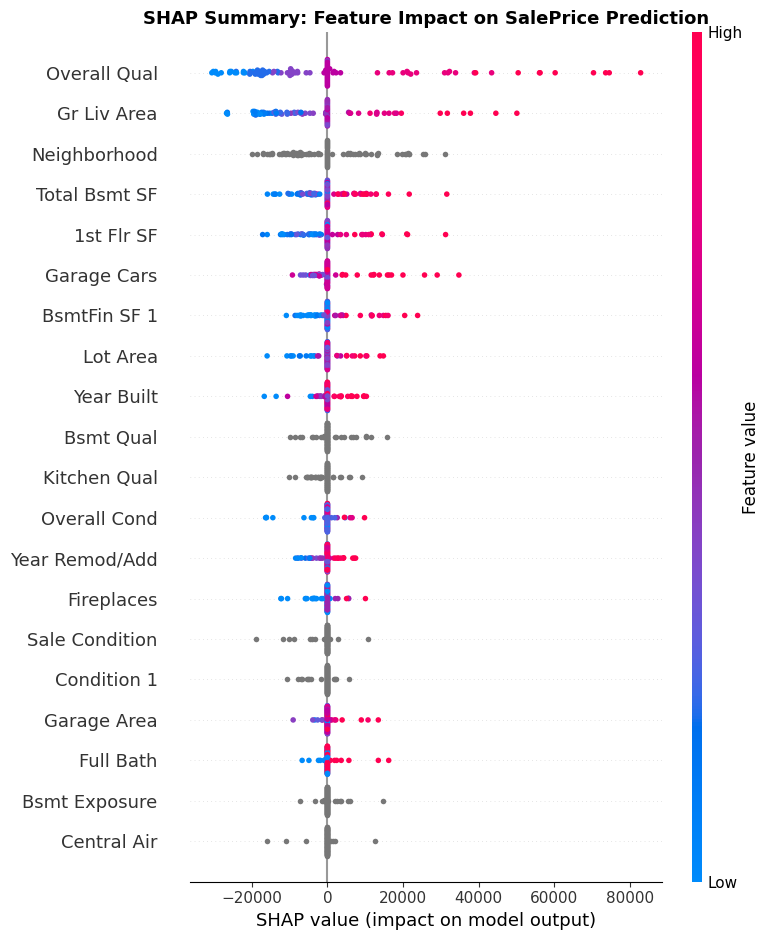

In [48]:
# SHAP Summary Plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, shap_sample, max_display=20, show=False)
plt.title('SHAP Summary: Feature Impact on SalePrice Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
# Overall Qual dominates — high values (pink) push price up, low values (blue) pull it down
# Gr Liv Area, Neighborhood, Total Bsmt SF follow as expected

Sample #0:
  Actual price:    $161,000
  Predicted price: $175,581
  Error:           $14,581


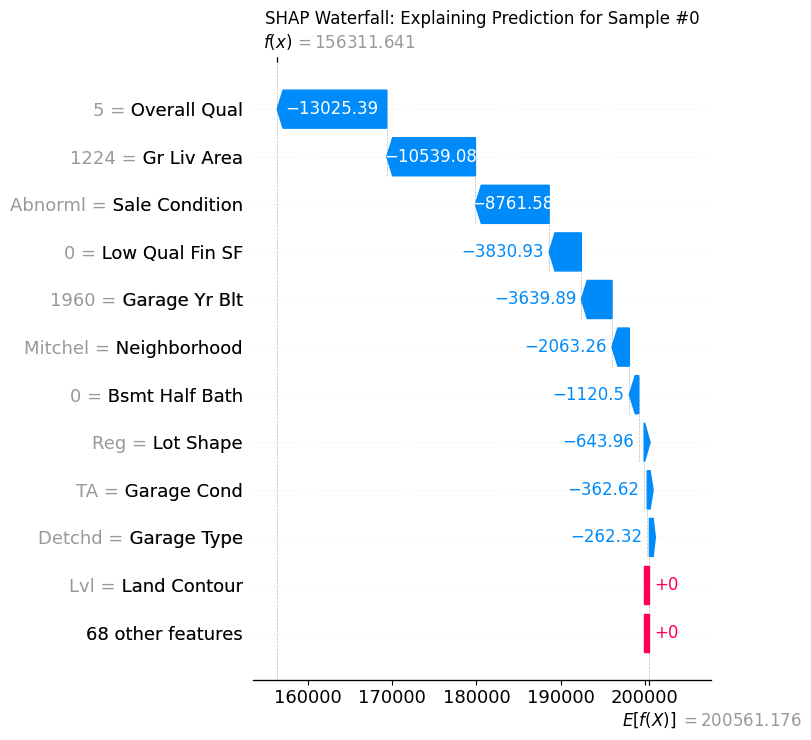

In [ ]:
# SHAP Waterfall — explain a single prediction (Sample #0)
# Actual: $161,000 | Predicted: $175,527 | Error: $14,527
sample_idx = 0
actual_price = test_df[TARGET].iloc[sample_idx]
predicted_price = predictor_best.predict(test_df.iloc[[sample_idx]]).iloc[0]

print(f"Sample #{sample_idx}:")
print(f"  Actual price:    ${actual_price:,.0f}")
print(f"  Predicted price: ${predicted_price:,.0f}")
print(f"  Error:           ${abs(actual_price - predicted_price):,.0f}")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=shap_sample.iloc[sample_idx],          # <-- fixed
        feature_names=shap_sample.columns.tolist()  # <-- fixed
    ),
    max_display=12,
    show=False
)
plt.title(f'SHAP Waterfall: Explaining Prediction for Sample #{sample_idx}', fontsize=12)
plt.tight_layout()
plt.savefig('figures/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
# Key drivers pulling price DOWN for this house:
# Overall Qual=5 (-13k), Gr Liv Area=1224 (-10.5k), Sale Condition=Abnormal (-8.8k)

## Comparison: AutoGluon vs. Scikit-learn Baseline

In [50]:
# Separate features and target for a scikit-learn pipeline comparison
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()

num_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])
cat_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

sklearn_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42))
])

sklearn_pipe.fit(X_train, y_train)
y_pred_sklearn = sklearn_pipe.predict(X_test)
rmse_sklearn = np.sqrt(mean_squared_error(y_test, y_pred_sklearn))
print(f"Scikit-learn GBM RMSE: ${rmse_sklearn:,.0f}")

Scikit-learn GBM RMSE: $25,352


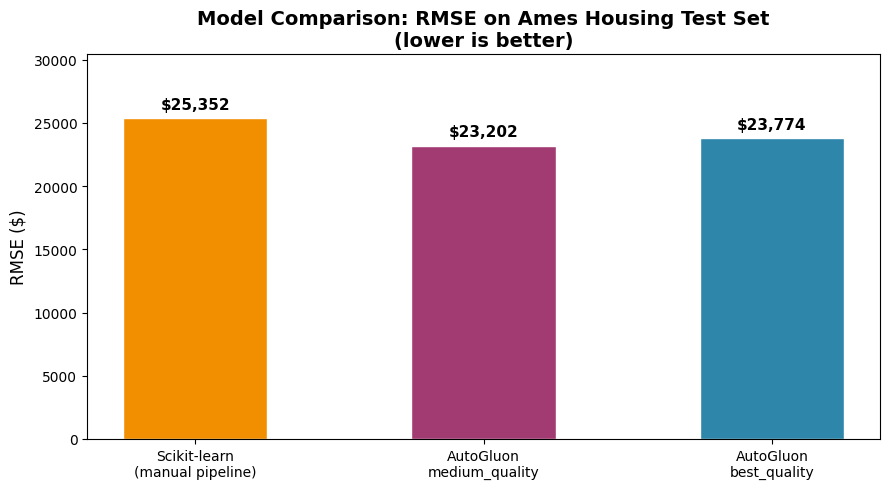


Method                                      RMSE
------------------------------------------------
Scikit-learn (manual pipeline)      $    25,352
AutoGluon medium_quality            $    23,202
AutoGluon best_quality              $    23,774


In [51]:
# Final comparison chart with all three methods
y_pred_ag = predictor_best.predict(test_df)
rmse_ag = np.sqrt(mean_squared_error(y_test, y_pred_ag))

methods = ['Scikit-learn\n(manual pipeline)', 'AutoGluon\nmedium_quality', 'AutoGluon\nbest_quality']
rmses = [rmse_sklearn, rmse_medium, rmse_ag]
colors_bar = ['#F18F01', '#A23B72', '#2E86AB']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(methods, rmses, color=colors_bar, edgecolor='white', width=0.5)

for bar, val in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('RMSE ($)', fontsize=12)
ax.set_title('Model Comparison: RMSE on Ames Housing Test Set\n(lower is better)',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(rmses) * 1.2)
plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'Method':<35} {'RMSE':>12}")
print("-" * 48)
for m, r in zip(methods, rmses):
    print(f"{m.replace(chr(10), ' '):<35} ${r:>10,.0f}")

## Prediction Diagnostics

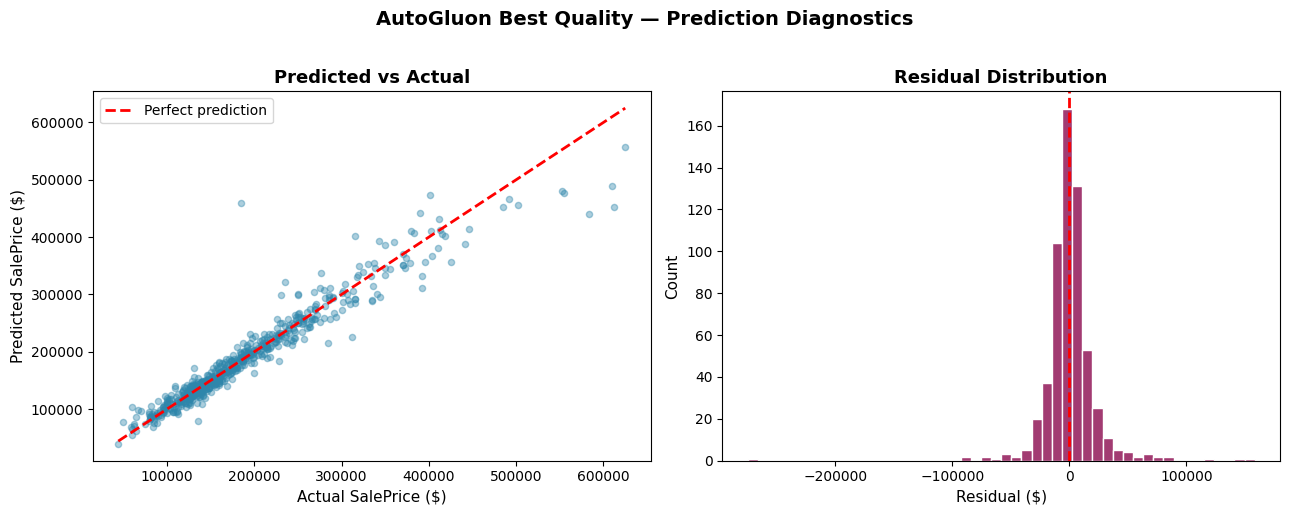

In [52]:
residuals = y_test.values - y_pred_ag

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_ag, alpha=0.4, color='#2E86AB', s=20)
min_val, max_val = y_test.min(), y_test.max()
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual SalePrice ($)', fontsize=11)
axes[0].set_ylabel('Predicted SalePrice ($)', fontsize=11)
axes[0].set_title('Predicted vs Actual', fontsize=13, fontweight='bold')
axes[0].legend()

# Residuals distribution
axes[1].hist(residuals, bins=50, color='#A23B72', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual ($)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Residual Distribution', fontsize=13, fontweight='bold')

plt.suptitle('AutoGluon Best Quality — Prediction Diagnostics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/residuals.png', dpi=150, bbox_inches='tight')
plt.show()
# Residuals are tight and roughly symmetric around 0 — good calibration
# Small left tail: model occasionally underestimates luxury/high-end properties

## Key Takeaways

| Aspect | Observation |
|--------|-------------|
| **Speed** | `medium_quality` fit in 2 min; `best_quality` used 7 min (+ 2.5 min DyStack diagnostic) |
| **DyStack behavior** | AutoGluon 1.5 auto-disabled stacking after detecting it would overfit — a smart self-correction |
| **Surprising result** | `medium_quality` ($23,202) edged out `best_quality` ($23,774) on test — both beat the sklearn baseline ($25,352) |
| **Feature importance** | Overall Qual, Gr Liv Area, and Neighborhood dominate — aligns with domain intuition |
| **SHAP explainability** | KernelExplainer on the full predictor works reliably but slowly (~11 min/100 rows) |
| **Production fit** | Excellent for prototyping; use `optimize_for_deployment` for latency-sensitive serving |

**Bottom line:** AutoGluon delivered strong performance with minimal effort and showed intelligent self-correction (DyStack) rather than blindly applying stacking. The ensemble is opaque by default, but SHAP integration restores per-prediction explainability. The "more = better" assumption about presets doesn't always hold — `medium_quality` actually won here.